In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings


In [2]:
HOME = "/scistor/ivm/the410/"

#HOME = "/home/thappe/" #snellius

In [3]:
os.chdir(f"{HOME}HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *

In [4]:
os.chdir(f"{HOME}/VAE3D/autoencoder_notebooks/LatentSpace/P1/")

from model.autoencoder_3d_model_v1 import CVAE

In [5]:
pwd

'/scistor/ivm/the410/VAE3D/autoencoder_notebooks/LatentSpace/P1'

In [5]:
### GLOBAL VARIABLES snellius

# os.chdir(HOME)

# data_path = "/home/thappe/data"
# data_path_heatwaves = f"{data_path}/heatwaves/"
# data_path_climate = data_path


In [6]:
### GLOBAL VARIABLES IVM

os.chdir(HOME)

data_path = "/scistor/ivm/the410/PAPER3"


In [7]:
ls /scistor/ivm/the410/PAPER3

t2m_data_from_snellius_for_gdbscan/
tf_records/
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


## LOADING DATA 

In [8]:
t2m_name = "t2m_minus_thermo" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

tf_record_file = f"{data_path}/tf_records/TF_record_ERA5_{t2m_name}_1940-2023_standardization_cut.tfrecord"

In [9]:
data = load_tfrecords_ERA5(tf_record_file)

2025-03-05 16:19:52.776511: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-03-05 16:19:52.776546: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: node015
2025-03-05 16:19:52.776551: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: node015
2025-03-05 16:19:52.776656: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 550.54.15
2025-03-05 16:19:52.776670: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 550.54.15
2025-03-05 16:19:52.776675: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 550.54.15


In [10]:
# #LOAD data from records
# data_train_raw = load_tfrecords(np.arange(101,115,1), norm_method)
# data_val_raw = load_tfrecords(np.arange(115,117,1), norm_method)

#Get a sample to use for visualisation during training
data_testbatch = data.map(parse_function_full_era5).take(1) #selecting only one for visualisation

data_parsed = data.map(parse_function_full_era5)

In [11]:
data_testbatch


for element in data_testbatch.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    date = str(element[1]) + "_" + str(element[2]) + "_" + str(element[3]) 

In [12]:
LONS= np.array([-74.53125 , -73.828125, -73.125   , -72.421875,
                   -71.71875 , -71.015625, -70.3125  , -69.609375,
                   -68.90625 , -68.203125, -67.5     , -66.796875,
                   -66.09375 , -65.390625, -64.6875  , -63.984375,
                   -63.28125 , -62.578125, -61.875   , -61.171875,
                   -60.46875 , -59.765625, -59.0625  , -58.359375,
                   -57.65625 , -56.953125, -56.25    , -55.546875,
                   -54.84375 , -54.140625, -53.4375  , -52.734375,
                   -52.03125 , -51.328125, -50.625   , -49.921875,
                   -49.21875 , -48.515625, -47.8125  , -47.109375,
                   -46.40625 , -45.703125, -45.      , -44.296875,
                   -43.59375 , -42.890625, -42.1875  , -41.484375,
                   -40.78125 , -40.078125, -39.375   , -38.671875,
                   -37.96875 , -37.265625, -36.5625  , -35.859375,
                   -35.15625 , -34.453125, -33.75    , -33.046875,
                   -32.34375 , -31.640625, -30.9375  , -30.234375,
                   -29.53125 , -28.828125, -28.125   , -27.421875,
                   -26.71875 , -26.015625, -25.3125  , -24.609375,
                   -23.90625 , -23.203125, -22.5     , -21.796875,
                   -21.09375 , -20.390625, -19.6875  , -18.984375,
                   -18.28125 , -17.578125, -16.875   , -16.171875,
                   -15.46875 , -14.765625, -14.0625  , -13.359375,
                   -12.65625 , -11.953125, -11.25    , -10.546875,
                    -9.84375 ,  -9.140625,  -8.4375  ,  -7.734375,
                    -7.03125 ,  -6.328125,  -5.625   ,  -4.921875,
                    -4.21875 ,  -3.515625,  -2.8125  ,  -2.109375,
                    -1.40625 ,  -0.703125,   0.      ,   0.703125,
                     1.40625 ,   2.109375,   2.8125  ,   3.515625,
                     4.21875 ,   4.921875,   5.625   ,   6.328125,
                     7.03125 ,   7.734375,   8.4375  ,   9.140625,
                     9.84375 ,  10.546875,  11.25    ,  11.953125,
                    12.65625 ,  13.359375,  14.0625  ,  14.765625,
                    15.46875 ,  16.171875,  16.875   ,  17.578125,
                    18.28125 ,  18.984375,  19.6875  ,  20.390625,
                    21.09375 ,  21.796875,  22.5     ,  23.203125,
                    23.90625 ,  24.609375,  25.3125  ,  26.015625,
                    26.71875 ,  27.421875,  28.125   ,  28.828125,
                    29.53125 ,  30.234375,  30.9375  ,  31.640625,
                    32.34375 ,  33.046875,  33.75    ,  34.453125,
                    35.15625 ,  35.859375,  36.5625  ,  37.265625,
                    37.96875 ,  38.671875,  39.375   ,  40.078125,
                    40.78125 ,  41.484375,  42.1875  ,  42.890625,
                    43.59375 ,  44.296875,  45.      ,  45.703125,
                    46.40625 ,  47.109375,  47.8125  ,  48.515625,
                    49.21875 ,  49.921875,  50.625   ,  51.328125,
                    52.03125 ,  52.734375,  53.4375  ,  54.140625,
                    54.84375 ,  55.546875,  56.25    ,  56.953125,
                    57.65625 ,  58.359375,  59.0625  ,  59.765625])
LATS = np.array([30.5262516 , 31.22800418, 31.92975673, 32.63150925,
                   33.33326174, 34.0350142 , 34.73676663, 35.43851902,
                   36.14027138, 36.8420237 , 37.54377599, 38.24552823,
                   38.94728044, 39.6490326 , 40.35078471, 41.05253678,
                   41.75428879, 42.45604076, 43.15779267, 43.85954452,
                   44.56129631, 45.26304804, 45.9647997 , 46.66655129,
                   47.3683028 , 48.07005424, 48.7718056 , 49.47355688,
                   50.17530806, 50.87705915, 51.57881013, 52.28056101,
                   52.98231178, 53.68406242, 54.38581295, 55.08756333,
                   55.78931357, 56.49106366, 57.19281359, 57.89456335,
                   58.59631292, 59.2980623 , 59.99981146, 60.7015604 ,
                   61.40330909, 62.10505753, 62.80680568, 63.50855352,
                   64.21030104, 64.9120482 , 65.61379497, 66.31554132,
                   67.01728721, 67.71903259, 68.42077741, 69.12252163,
                   69.82426517, 70.52600796, 71.22774993, 71.92949096,
                   72.63123095, 73.33296977, 74.03470726, 74.73644324]) 

def plot_sample(x, norm_method, title):
        
  """Plots one sample (either input or predicted) """
#   matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 40})
#   matplotlib.rc('text', usetex=True)
  fig_width = 60
  fig_height = 10
  fig, axes = plt.subplots(2, 5, figsize=(fig_width, fig_height))

  if norm_method == "standardized":
    vmin, vmax = -3, 3
  elif norm_method == "standardization_cut":
    vmin, vmax = -1, 1
  else:
    vmin, vmax = 0, 1

  for t in range(5):
    stream = x[:, :, t, 0]
    psl    = x[:, :, t, 1]

    #plot stream function
    ax = plt.subplot(2, 5, t + 1, projection=ccrs.PlateCarree())
    cs = ax.pcolormesh(LONS, LATS, stream, transform=ccrs.PlateCarree(),
                       cmap="seismic", vmin=vmin, vmax=vmax)
    ax.coastlines()
    ax.set_title("Day {}".format(t))
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlabels_top    = False
    gl.xlabels_bottom = False
    gl.ylabels_right  = False
    if t == 0:
      gl.ylabels_left = True
    else:
      gl.ylabels_left = False

    #plot sea level pressure
    ax = plt.subplot(2, 5, t + 6, projection=ccrs.PlateCarree())
    cs = ax.pcolormesh(LONS, LATS, psl, transform=ccrs.PlateCarree(),
                       cmap="seismic", vmin=vmin, vmax=vmax)
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator([-60, -40, -20, 0, 20, 40])
    gl.xlabels_top   = False
    gl.ylabels_right = False
    if t == 0:
      gl.ylabels_left = True
    else:
      gl.ylabels_left = False    

  h_space = -0.14
  #w_space = h_space * fig_height / fig_width
  w_space = 0.03
  fig.subplots_adjust(wspace=w_space, hspace=h_space)
  fig.subplots_adjust(right=0.95)
  ax_cbar = fig.add_axes([0.96, 0.165, 0.01, 0.675])
  fig.colorbar(cs, cax=ax_cbar)

  plt.title(title)

  plt.show()
  plt.close()

In [13]:
def reconstruct_VAE_ERA5(model_file, L,  data_testbatch):
    regularizer = tf.keras.regularizers.L2(0.2)
    model = CVAE(L, filter_scaling=4)
    model.built = True
    model.load_weights(f"{model_file}")
        
    warnings.filterwarnings("ignore")
    
#     for element in data_testbatch.as_numpy_iterator(): #to convert to numpy elements
#     array = np.transpose(element[0])
#     stream_in = array[0, :, :, :] 
#     psl_in = array[1, :, :, :]
#     date = str(element[1]) + "_" + str(element[2]) + "_" + str(element[3]) 
    
    test_sample = np.zeros((1, 192, 64, 5, 2))
    for element in data_testbatch.as_numpy_iterator():
        test_sample[0] = element[0]
        test_sample_transposed = np.transpose(element[0], (1, 0, 2, 3))
    plot_sample(test_sample_transposed, "standardization_cut", "True Sample")
    
    
    
    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)
    predicted = model.decode(z, apply_sigmoid=False)
    predicted = predicted[0,:,:,:,:]
    predicted_transposed = np.transpose(predicted, (1, 0, 2, 3))
    plot_sample(predicted_transposed, "standardization_cut", "Predicted Sample")


def get_r2_reconstructed_ERA5(model_file, L,  data_parsed):
    from sklearn.metrics import r2_score
    
    regularizer = tf.keras.regularizers.L2(0.2)
    model = CVAE(L, filter_scaling=4)
    model.built = True
    model.load_weights(f"{model_file}")
        
    warnings.filterwarnings("ignore")

    
    test_sample = np.zeros((1, 192, 64, 5, 2))
    
    r2_totals = []
    
    for element in data_parsed.as_numpy_iterator():
        test_sample[0] = element[0]
        test_sample_transposed = np.transpose(element[0], (1, 0, 2, 3))    
        
        mean, logvar = model.encode(test_sample)
        z = model.reparameterize(mean, logvar)
        predicted = model.decode(z, apply_sigmoid=False)
        predicted = predicted[0,:,:,:,:]
        predicted_transposed = np.transpose(predicted, (1, 0, 2, 3))
        
        r2 = r2_score(test_sample_transposed.flatten(), predicted_transposed.flatten())
        r2_totals.append(r2)

    return r2_totals


In [14]:
pwd

'/scistor/ivm/the410'

In [15]:
VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5")

In [16]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/scistor/ivm/the410/PAPER3/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


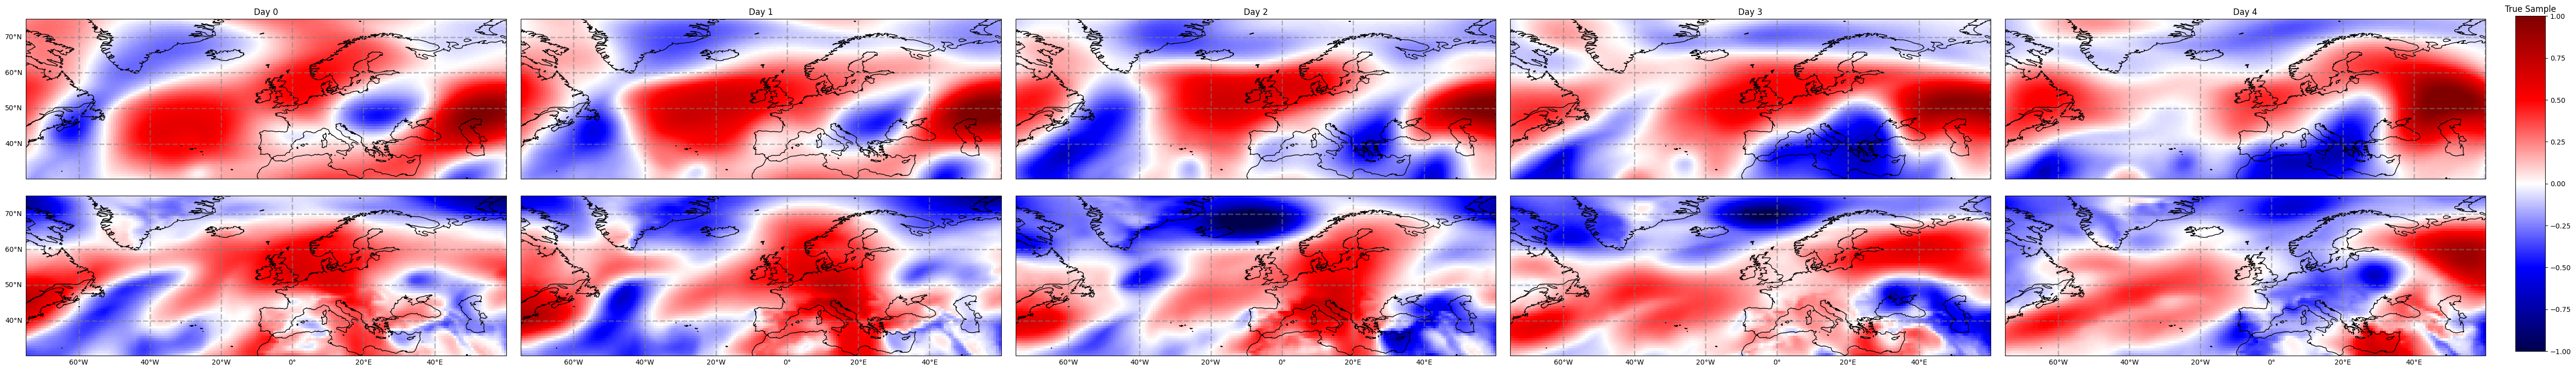

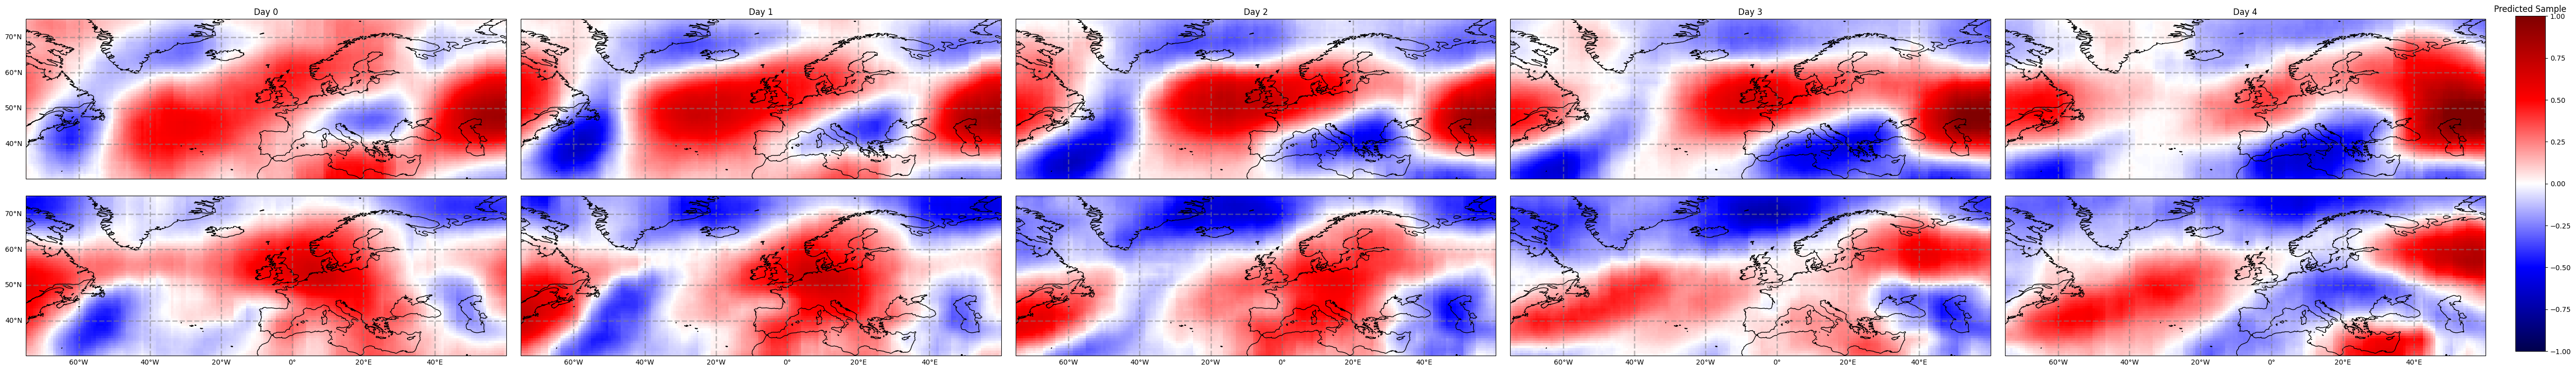

TypeError: cannot unpack non-iterable NoneType object

In [17]:
print(VAE_model[1])

reconstruct_VAE_ERA5(VAE_model[1], VAE_model[0], data_testbatch)

In [19]:
print(VAE_model[1])

r2_era5 = get_r2_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed)


/scistor/ivm/the410/PAPER3/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


In [20]:
len(r2_era5)

739

In [21]:
np.mean(r2_era5)


0.8890256967603799

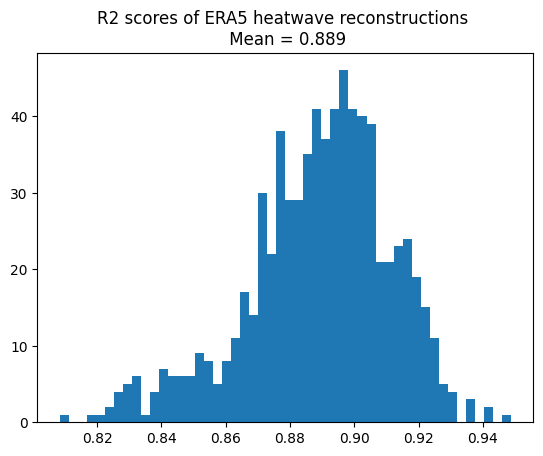

In [22]:

plt.hist(r2_era5, bins=50)
plt.title(f"R2 scores of ERA5 heatwave reconstructions \n Mean = {round(np.mean(r2_era5), 3)}")
plt.show()

### bij welk cluster horen de heatwaves?

In [23]:
def get_heatwave_means(model_file, L, data_parsed):
    
    regularizer = tf.keras.regularizers.L2(0.2)
    model = CVAE(L, filter_scaling=4)
    model.built = True
    model.load_weights(f"{model_file}")
        
    warnings.filterwarnings("ignore")

    
    test_sample = np.zeros((1, 192, 64, 5, 2))
    
    heatwave_means = []
    
    for element in data_parsed.as_numpy_iterator():
        test_sample[0] = element[0]
        test_sample_transposed = np.transpose(element[0], (1, 0, 2, 3))    
        mean, logvar = model.encode(test_sample)
        heatwave_means.append(mean.numpy()[0])

    return heatwave_means

In [24]:
heatwave_means = get_heatwave_means(VAE_model[1], VAE_model[0], data_parsed)

In [ ]:
## save the means to csv



In [ ]:
## encode the heatwaves

#filename = 'test.csv' # kmeans of L-2048, AE

# filename= f"{HOME}VAE3D/autoencoder_results/csv_files/Heatwave_means_VAE_L128_1000epochs.csv"
# heatwave_means = np.loadtxt(filename,delimiter=",", skiprows=1 )

In [25]:
heatwave_means[0]

array([ 1.1091595 , -0.49508706,  0.40897438,  0.8974355 ,  0.19032468,
        0.7714641 ,  2.07929   , -0.4397501 , -1.3065593 ,  0.5271634 ,
       -2.6210034 ,  0.5024593 ,  0.6392352 ,  0.6655764 , -0.46631023,
        0.5811173 ,  2.4128637 ,  0.7351508 , -0.58341897,  1.1729548 ,
       -0.47975028,  0.7085057 ,  0.73444945, -0.4702311 , -0.43640643,
       -0.6239401 , -2.0105667 , -0.8150123 , -0.30229607, -2.7790174 ,
        0.3548306 , -1.3334208 ,  1.3284944 , -0.08923689,  0.58923787,
        1.7836196 , -0.26438856,  1.6155093 , -0.72140634, -0.45053995,
       -1.1958696 , -0.68308204,  2.79305   , -0.78627986, -0.02987562,
        0.20385922, -0.48647374, -3.6597307 , -0.48939168,  0.1823532 ,
        1.1504198 ,  1.6547153 ,  1.1760782 , -0.38526157, -1.3304876 ,
        0.11990003,  0.8019634 ,  0.6850579 , -0.8143528 ,  0.03121793,
       -1.8029584 , -1.0858666 ,  0.8555274 , -1.2319669 ,  0.43533093,
       -1.8878994 ,  1.2573333 , -1.6369095 , -3.2489388 , -1.31

In [26]:
## load kmeans / GMM 

import pickle
import scipy


to_cluster = np.array(heatwave_means)

## to open the GM model
f='/scistor/ivm/the410/VAE3D/autoencoder_notebooks/LatentSpace/GMM.pkl'
GM = pickle.load(open(f, 'rb'))

## predict heatwave clusters 
y_pred_GM = GM.fit_predict(to_cluster)

#to get individual probabilities of belonging to cluster
probs = GM.predict_proba(to_cluster)

#to get the centers
GM_centers = np.empty(shape=(GM.n_components, to_cluster.shape[1]))
for i in range(GM.n_components):
    density = scipy.stats.multivariate_normal(cov=GM.covariances_[i], mean=GM.means_[i]).logpdf(to_cluster)
    GM_centers[i, :] = to_cluster[np.argmax(density)]

In [ ]:
## TSNE space? 

## clusters over time



In [178]:
## plotting over time

In [33]:
from datetime import date
dates = []
for element in data_parsed.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    iso_date = date(element[1], element[2], element[3]).isoformat() #year, month, date 
    date_date = date.fromisoformat(iso_date) #to datetime object 
    dates.append(date_date)

1940
1940
1940
1940
1940
1940
1940
1940
1941
1941
1941
1941
1941
1941
1942
1942
1942
1942
1942
1942
1942
1942
1942
1943
1943
1943
1943
1943
1943
1943
1944
1944
1944
1944
1944
1944
1944
1944
1944
1944
1944
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1945
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1946
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1947
1948
1948
1948
1948
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1949
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1950
1951
1951
1951
1951
1951
1951
1951
1951
1951
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1952
1953
1953
1953
1953
1953
1953
1954
1955
1955
1955
1955
1955
1955
1955
1955
1955
1955
1955
1955
1955
1955
1955
1956
1956
1956
1956


In [32]:
dates

[datetime.date(1940, 8, 2),
 datetime.date(1940, 8, 3),
 datetime.date(1940, 8, 4),
 datetime.date(1940, 8, 6),
 datetime.date(1940, 8, 7),
 datetime.date(1940, 8, 18),
 datetime.date(1940, 8, 16),
 datetime.date(1940, 8, 29),
 datetime.date(1941, 7, 1),
 datetime.date(1941, 7, 4),
 datetime.date(1941, 7, 18),
 datetime.date(1941, 7, 25),
 datetime.date(1941, 8, 26),
 datetime.date(1941, 8, 24),
 datetime.date(1942, 7, 14),
 datetime.date(1942, 7, 25),
 datetime.date(1942, 7, 27),
 datetime.date(1942, 7, 30),
 datetime.date(1942, 8, 15),
 datetime.date(1942, 8, 18),
 datetime.date(1942, 8, 18),
 datetime.date(1942, 8, 18),
 datetime.date(1942, 8, 25),
 datetime.date(1943, 7, 20),
 datetime.date(1943, 7, 25),
 datetime.date(1943, 8, 2),
 datetime.date(1943, 7, 28),
 datetime.date(1943, 8, 10),
 datetime.date(1943, 8, 12),
 datetime.date(1943, 8, 29),
 datetime.date(1944, 8, 2),
 datetime.date(1944, 8, 2),
 datetime.date(1944, 8, 9),
 datetime.date(1944, 8, 12),
 datetime.date(1944, 8, 2

In [119]:
## initialize empty dictionary 
year_counts = {}
for year in np.arange(1940, 2024, 1):
    year_counts[year] = {1:0, 2:0, 3:0, 4:0}
    

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts[date.year][cluster_id] += 1 #add one to this year and cluster count

In [145]:
year_counts_reversed = {}
for cluster_id in [1,2,3,4]:
    cluster_ids = {}
    for year in np.arange(1940, 2024, 1):
        cluster_ids[year] = 0
    year_counts_reversed[cluster_id] = cluster_ids

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts_reversed[cluster_id][date.year] += 1 #add one to this year and cluster count
    

In [29]:
year_counts_for_plotting = {}

for year in np.arange(1940, 2024, 1):
    year_counts_for_plotting[year] = [0,0,0,0]

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts_for_plotting[date.year][cluster] += 1 #add one to this year and cluster count
    
# year_counts_for_plotting

In [28]:
years = np.arange(1940, 2024, 1)
year_counts_for_plotting_reversed  = {}


for cluster_id in [1,2,3,4]:
    year_counts_for_plotting_reversed[cluster_id] = np.zeros_like(years)
    

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_index = np.where(years==date.year)
    year_counts_for_plotting_reversed[cluster_id][year_index] += 1 #add one to this year and cluster count
    
# year_counts_for_plotting_reversed

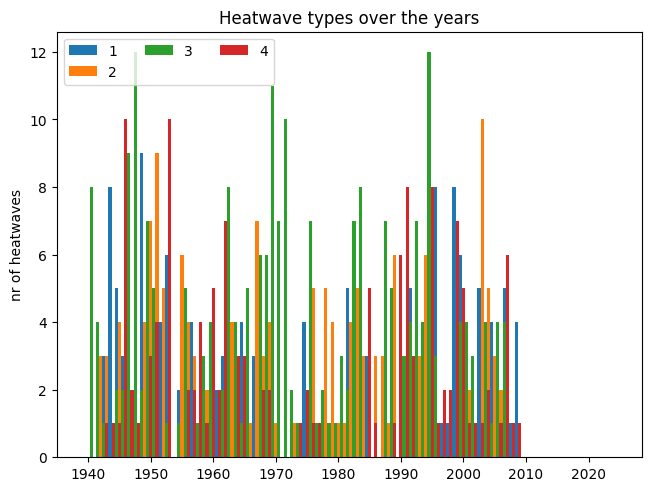

In [30]:
years = np.arange(1940, 2024, 1)

x = np.arange(len(years))  # the label locations
width = 0.5  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for cluster_id, counts in year_counts_for_plotting_reversed.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=cluster_id)
#     ax.bar_label(rects, padding=3)
    multiplier += 1

# # Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('nr of heatwaves')
ax.set_title('Heatwave types over the years')
ax.set_xticks(np.arange(len(np.arange(1940,2024,10)))*10 +width, np.arange(1940,2024,10))
ax.legend(loc='upper left', ncols=3)

plt.show()

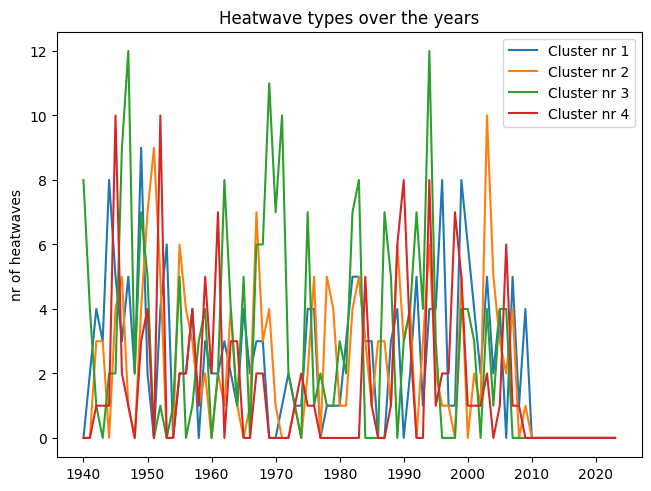

In [31]:
years = np.arange(1940, 2024, 1)

fig, ax = plt.subplots(layout='constrained')

for cluster_id, counts in year_counts_for_plotting_reversed.items():
    ax.plot(years, counts, label=f"Cluster nr {cluster_id}")
    
# # Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('nr of heatwaves')
ax.set_title('Heatwave types over the years')
ax.set_xticks(np.arange(1940,2024,10))
ax.legend(loc='upper right', ncols=1)

plt.show()

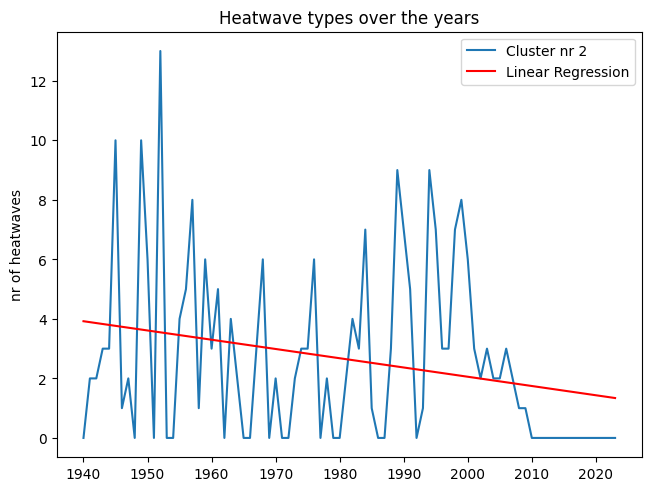

In [207]:
years = np.arange(1940, 2024, 1)

fig, ax = plt.subplots(layout='constrained')

cluster_id = 2

ax.plot(years, year_counts_for_plotting_reversed[cluster_id], label=f"Cluster nr {cluster_id}")
    
    
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(years.reshape(-1, 1), year_counts_for_plotting_reversed[cluster_id])
Y = reg.predict(years.reshape(-1, 1))
ax.plot(years, Y, label=f"Linear Regression", c="red")

# # Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('nr of heatwaves')
ax.set_title('Heatwave types over the years')
ax.set_xticks(np.arange(1940,2024,10))
ax.legend(loc='upper right', ncols=1)

plt.show()